In [8]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import string
from sklearn.metrics import roc_auc_score, roc_curve

In [9]:
sns.set(font_scale=2)
sns.set_style("darkgrid")
# plt.rcParams['xtick.major.size'] = 20
plt.rcParams["xtick.major.width"] = 3
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True

In [10]:
fig4 = pd.read_csv('/home/ybai31/might/revised_might/fig/fig4.csv')



0.5
0.70

1


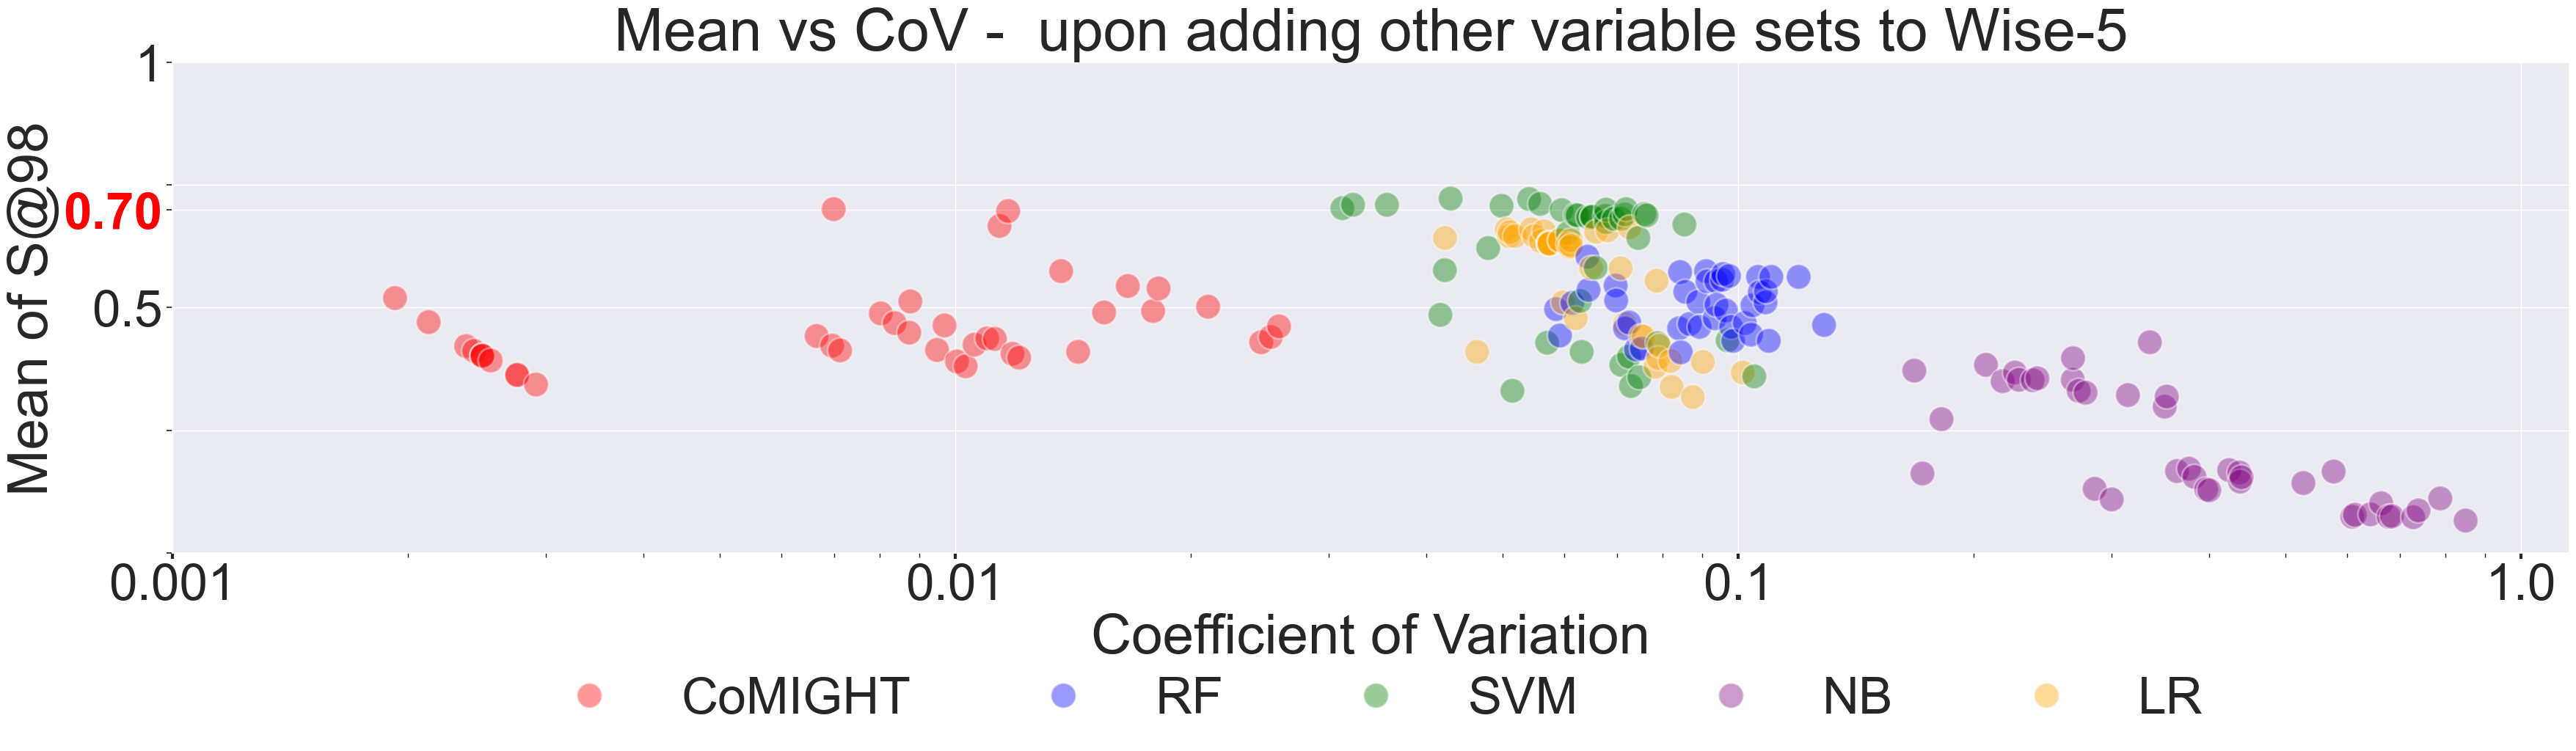

In [14]:
import matplotlib.ticker as ticker 

fontsize = 50
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(35, 10), constrained_layout=True)
ax_i = ax
palette = {
    'might': 'red',  
    'rf': 'blue',    
    'svm': 'green',  
    'nb': 'purple',  
    'lr': 'orange' 
}

g = sns.scatterplot(
    x="CoV",
    y="mean",
    hue="Classifier",
    data=fig4,
    s=600,
    alpha=0.4,
    ax=ax_i,
    palette=palette
)
empty_labels = ["" for _ in range(fig4.shape[0]) ]



ax_i.set_ylim([0, 1.0])
ax_i.set_xscale('log')
# ax_i.set_xlim([0,1.0])
# ax_i.xaxis.set_minor_locator(ticker.NullLocator())
ax_i.set_yticks([0,0.25,0.5,0.70,0.75,1],["","",0.5,"0.70","",1],fontsize=fontsize)
for tick in ax_i.get_yticklabels():
    print(tick.get_text())
    if tick.get_text() == "0.70":
        tick.set_color("red")
        tick.set_fontweight("bold")
ax_i.set_ylabel('Mean of S@98', fontsize=fontsize+5)
ax_i.set_xlabel('Coefficient of Variation', fontsize=fontsize+5)
# ticks = [min_cov,max_cov,max_cov_rf,max_cov_all]
# ticks = [0.001,0.007,0.01,0.03,0.1,1.0]
ticks = [0.001,0.01,0.1,1.0]
ax_i.set_xticks(ticks)
ax_i.set_xticklabels([str(tick) for tick in ticks], fontsize=fontsize)
# for tick in ax_i.get_xticklabels():
#     print(tick.get_text())
#     if tick.get_text() == "0.007":
#         tick.set_color("red")
#         tick.set_fontweight("bold")
# for tick in ax_i.get_xticklabels():
#     print(tick.get_text())
#     if tick.get_text() == "0.03":
#         tick.set_color("green")
#         tick.set_fontweight("bold")

ax_i.set_title('Mean vs CoV -  upon adding other variable sets to Wise-5', fontsize=fontsize+8)

legend_labels = {'rf': 'RF', 'svm': 'SVM', 'might': 'CoMIGHT', 'nb': 'NB', 'lr': 'LR'}


desired_order = ['might', 'rf', 'svm', 'nb', 'lr']
handles, labels = plt.gca().get_legend_handles_labels()
legend_dict = dict(zip(labels, handles))
reordered_handles = [legend_dict[label] for label in desired_order if label in legend_dict]
new_labels = [legend_labels[label] for label in desired_order]  
plt.legend(reordered_handles, new_labels,
           loc="center", bbox_to_anchor=(0.5, -0.3),
           ncol=len(desired_order), frameon=False,
           fontsize=fontsize)

plt.show()